In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multitest import fdrcorrection_twostage

import warnings
warnings.filterwarnings("ignore")

In [23]:
cd C:\Users\tr432\Downloads\filter_GutLungAxis_Week1

C:\Users\tr432\Downloads\filter_GutLungAxis_Week1


In [24]:
## 리눅스 lefse 환경의 run_lefse.py 단계에서 -a 1.0 / -w 1.0 / -l 0 으로 설정한 후 나온 파일 (모든 features의 p-value가 나와있는 파일)을 넣어야함
# -> 그래야 fdr correction 가능
df = pd.read_csv('AlDEx2_Group+Initial_b.w_BKY.csv')

df.rename(columns={df.columns[0]: "Features"}, inplace=True)
df.rename(columns={df.columns[3]: "p-val"}, inplace=True)
df.rename(columns={df.columns[5]: "effect"}, inplace=True)
df.rename(columns={df.columns[4]: "q-val"}, inplace=True)

df["effect"] = pd.to_numeric(df["effect"], errors="coerce")
df["Group"] = pd.NA  ## Group 컬럼 초기화 (NA)
df.loc[df["effect"] < 0, "Group"] = "Control"
df.loc[df["effect"] > 0, "Group"] = "VNAM"

df.head(5)

,Features,group1,group2,p-val,q-val,effect,Group
0,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,Control,VNAM,9.763049e-19,2.499341e-16,12.267145,VNAM
1,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,Control,VNAM,7.118108e-03,3.748195e-02,-1.459401,Control
2,d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lac...,Control,VNAM,4.849982e-01,3.946086e-01,-0.384829,Control
3,d__Bacteria;p__Actinomycetota;c__Actinomycetes...,Control,VNAM,1.933222e-01,2.251531e-01,0.479958,VNAM
4,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,Control,VNAM,3.324495e-01,3.826320e-01,0.022867,VNAM


In [25]:
new_cols = df['Features'].str.split(';', expand=True)
new_cols.columns = ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus']

df = pd.concat([new_cols, df], axis=1)
df = df.drop(columns=['Features'])

## 원하는 taxa level + 그룹명만 가져옴
cols = ['Phylum', 'Family', 'Genus'] + df.columns[6:].tolist()
df = df[cols]

df = df.replace('__', '_', regex=True)

df

,Phylum,Family,Genus,group1,group2,p-val,q-val,effect,Group
0,p_Pseudomonadota,f_Enterobacteriaceae_A_725029,_,Control,VNAM,9.763049e-19,2.499341e-16,12.267145,VNAM
1,p_Bacteroidota,f_Bacteroidaceae,g_Phocaeicola_A,Control,VNAM,7.118108e-03,3.748195e-02,-1.459401,Control
2,p_Bacillota_I,f_Lactobacillaceae,g_Ligilactobacillus,Control,VNAM,4.849982e-01,3.946086e-01,-0.384829,Control
3,p_Actinomycetota,f_Bifidobacteriaceae,g_Bifidobacterium_388775,Control,VNAM,1.933222e-01,2.251531e-01,0.479958,VNAM
4,p_Bacteroidota,f_Tannerellaceae,g_Parabacteroides_B_862066,Control,VNAM,3.324495e-01,3.826320e-01,0.022867,VNAM
...,...,...,...,...,...,...,...,...,...
251,p_Pseudomonadota,f_Beijerinckiaceae,g_Methylobacterium,Control,VNAM,6.196712e-02,1.414668e-01,0.892629,VNAM
252,p_Pseudomonadota,f_Burkholderiaceae_A_595421,g_Ralstonia,Control,VNAM,3.712275e-02,1.186815e-01,0.918713,VNAM
253,p_Actinomycetota,_,_,Control,VNAM,4.417512e-02,1.186815e-01,0.921340,VNAM
254,p_Bacillota_A_368345,f_Eubacteriaceae,g_Eubacterium_O_258270,Control,VNAM,4.289012e-02,1.186815e-01,0.850146,VNAM


In [26]:
df[df['Family'] == 'f_Muribaculaceae']

,Phylum,Family,Genus,group1,group2,p-val,q-val,effect,Group
20,p_Bacteroidota,f_Muribaculaceae,g_Amulumruptor,Control,VNAM,0.140975,0.185435,-0.663134,Control
56,p_Bacteroidota,f_Muribaculaceae,g_Lepagella,Control,VNAM,0.446292,0.394609,0.400463,VNAM
217,p_Bacteroidota,f_Muribaculaceae,_,Control,VNAM,0.232682,0.264594,0.449864,VNAM


In [27]:
mask = ((df['Family'] == 'f_Muribaculaceae') &
        (df['Genus'].isna() | (df['Genus'] == '_')))

df.loc[mask, 'Genus'] = 'f_Muribaculaceae; g_unclassified'

In [28]:
df[df['Family'] == 'f_Muribaculaceae']

,Phylum,Family,Genus,group1,group2,p-val,q-val,effect,Group
20,p_Bacteroidota,f_Muribaculaceae,g_Amulumruptor,Control,VNAM,0.140975,0.185435,-0.663134,Control
56,p_Bacteroidota,f_Muribaculaceae,g_Lepagella,Control,VNAM,0.446292,0.394609,0.400463,VNAM
217,p_Bacteroidota,f_Muribaculaceae,f_Muribaculaceae; g_unclassified,Control,VNAM,0.232682,0.264594,0.449864,VNAM


In [29]:
df2 = df.dropna(subset=['Group'])
df2 = df2.dropna(subset=['Genus'])
df2 = df2[df2['Genus'].astype(str).str.startswith(('g_', 'f_Muribaculaceae'))].copy()
df2

,Phylum,Family,Genus,group1,group2,p-val,q-val,effect,Group
1,p_Bacteroidota,f_Bacteroidaceae,g_Phocaeicola_A,Control,VNAM,0.007118,0.037482,-1.459401,Control
2,p_Bacillota_I,f_Lactobacillaceae,g_Ligilactobacillus,Control,VNAM,0.484998,0.394609,-0.384829,Control
3,p_Actinomycetota,f_Bifidobacteriaceae,g_Bifidobacterium_388775,Control,VNAM,0.193322,0.225153,0.479958,VNAM
4,p_Bacteroidota,f_Tannerellaceae,g_Parabacteroides_B_862066,Control,VNAM,0.332449,0.382632,0.022867,VNAM
5,p_Bacteroidota,f_Bacteroidaceae,g_Bacteroides_H_857956,Control,VNAM,0.170239,0.206734,-0.112422,Control
...,...,...,...,...,...,...,...,...,...
250,p_Actinomycetota,f_Microbacteriaceae,g_Curtobacterium,Control,VNAM,0.040054,0.118681,0.858385,VNAM
251,p_Pseudomonadota,f_Beijerinckiaceae,g_Methylobacterium,Control,VNAM,0.061967,0.141467,0.892629,VNAM
252,p_Pseudomonadota,f_Burkholderiaceae_A_595421,g_Ralstonia,Control,VNAM,0.037123,0.118681,0.918713,VNAM
254,p_Bacillota_A_368345,f_Eubacteriaceae,g_Eubacterium_O_258270,Control,VNAM,0.042890,0.118681,0.850146,VNAM


In [30]:
df2[df2['Family'] == 'f_Muribaculaceae']

,Phylum,Family,Genus,group1,group2,p-val,q-val,effect,Group
20,p_Bacteroidota,f_Muribaculaceae,g_Amulumruptor,Control,VNAM,0.140975,0.185435,-0.663134,Control
56,p_Bacteroidota,f_Muribaculaceae,g_Lepagella,Control,VNAM,0.446292,0.394609,0.400463,VNAM
217,p_Bacteroidota,f_Muribaculaceae,f_Muribaculaceae; g_unclassified,Control,VNAM,0.232682,0.264594,0.449864,VNAM


In [31]:
## (선택1) FDR (BKY)

#rej, qvals, _, _ = fdrcorrection_twostage(df2["p-val"].values, alpha=0.05, method="bky")  ## BKY(2006) two-stage linear step-up
#df2["q-val"] = qvals

print(df2[["p-val", "q-val"]])
print(df2[df2["p-val"] < 0.05].shape[0])
print(df2[df2["q-val"] < 0.05].shape[0])

        p-val     q-val
1    0.007118  0.037482
2    0.484998  0.394609
3    0.193322  0.225153
4    0.332449  0.382632
5    0.170239  0.206734
..        ...       ...
250  0.040054  0.118681
251  0.061967  0.141467
252  0.037123  0.118681
254  0.042890  0.118681
255  0.043147  0.118681

[222 rows x 2 columns]
77
39


In [32]:
df_raw = df2.copy()
df_raw['Phylum'] = df_raw['Phylum'].str.replace(r'^p_', '', regex=True)
df_raw['Family'] = df_raw['Family'].str.replace(r'^f_', '', regex=True)
df_raw['Genus']  = df_raw['Genus'] .str.replace(r'^g_', '', regex=True)

#df_ld2.set_index('Genus', inplace=True)
#df_raw.loc[df_raw['Group'] == 'Control', 'effect'] *= -1  #Edit: LD2 값을 음수로 설정할 그룹명 입력

df_raw

,Phylum,Family,Genus,group1,group2,p-val,q-val,effect,Group
1,Bacteroidota,Bacteroidaceae,Phocaeicola_A,Control,VNAM,0.007118,0.037482,-1.459401,Control
2,Bacillota_I,Lactobacillaceae,Ligilactobacillus,Control,VNAM,0.484998,0.394609,-0.384829,Control
3,Actinomycetota,Bifidobacteriaceae,Bifidobacterium_388775,Control,VNAM,0.193322,0.225153,0.479958,VNAM
4,Bacteroidota,Tannerellaceae,Parabacteroides_B_862066,Control,VNAM,0.332449,0.382632,0.022867,VNAM
5,Bacteroidota,Bacteroidaceae,Bacteroides_H_857956,Control,VNAM,0.170239,0.206734,-0.112422,Control
...,...,...,...,...,...,...,...,...,...
250,Actinomycetota,Microbacteriaceae,Curtobacterium,Control,VNAM,0.040054,0.118681,0.858385,VNAM
251,Pseudomonadota,Beijerinckiaceae,Methylobacterium,Control,VNAM,0.061967,0.141467,0.892629,VNAM
252,Pseudomonadota,Burkholderiaceae_A_595421,Ralstonia,Control,VNAM,0.037123,0.118681,0.918713,VNAM
254,Bacillota_A_368345,Eubacteriaceae,Eubacterium_O_258270,Control,VNAM,0.042890,0.118681,0.850146,VNAM


In [33]:
df_raw[df_raw['Family'] == 'Muribaculaceae']

,Phylum,Family,Genus,group1,group2,p-val,q-val,effect,Group
20,Bacteroidota,Muribaculaceae,Amulumruptor,Control,VNAM,0.140975,0.185435,-0.663134,Control
56,Bacteroidota,Muribaculaceae,Lepagella,Control,VNAM,0.446292,0.394609,0.400463,VNAM
217,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_unclassified,Control,VNAM,0.232682,0.264594,0.449864,VNAM


In [34]:
df_ld3 = df_raw[(df_raw['q-val'] < 0.05)].copy()
#df_ld3.set_index('Genus', inplace=True)
print(df_ld3.head(3))
print(df_ld3.shape[0])

               Phylum                       Family          Genus   group1  \
1        Bacteroidota               Bacteroidaceae  Phocaeicola_A  Control   
15  Verrucomicrobiota              Akkermansiaceae    Akkermansia  Control   
25     Pseudomonadota  Enterobacteriaceae_A_732334        Proteus  Control   

   group2     p-val     q-val    effect    Group  
1    VNAM  0.007118  0.037482 -1.459401  Control  
15   VNAM  0.000786  0.006300 -1.200264  Control  
25   VNAM  0.003413  0.020905  0.875691     VNAM  
39


In [35]:
df_ld3 = df_ld3.sort_values(by='effect')

#df_ld3.to_csv('df_ld3_qval.05_GutLungAxis.csv', index=False)
df_ld3

,Phylum,Family,Genus,group1,group2,p-val,q-val,effect,Group
52,Bacillota_A_368345,Lachnospiraceae,Kineothrix,Control,VNAM,0.000029,0.002037,-2.206728,Control
87,Bacillota_A_368345,CAG-508,CAG-269,Control,VNAM,0.000032,0.002037,-2.056061,Control
53,Bacillota_A_368345,Lachnospiraceae,UBA3282,Control,VNAM,0.000024,0.002037,-2.002078,Control
48,Bacillota_A_368345,Clostridiaceae_222000,Dwaynesavagella,Control,VNAM,0.000092,0.002877,-1.993320,Control
43,Bacillota_B_370539,Peptococcaceae_369362,Peptococcus,Control,VNAM,0.000060,0.002755,-1.936369,Control
33,Bacillota_A_368345,UBA1381,Hominilimicola,Control,VNAM,0.000219,0.004084,-1.926325,Control
46,Bacillota_A_368345,Lachnospiraceae,COE1,Control,VNAM,0.000068,0.002755,-1.818408,Control
32,Bacillota_A_368345,CAG-508,UMGS1994,Control,VNAM,0.000218,0.004084,-1.736432,Control
64,Bacillota_A_368345,CAG-508,,Control,VNAM,0.000193,0.004084,-1.721376,Control
79,Bacillota_A_368345,Lachnospiraceae,Petralouisia,Control,VNAM,0.000076,0.002755,-1.653998,Control


In [36]:
df_ld3.shape

(39, 9)

In [37]:
banned_prefix = ['UBA', 'UMGS', 'COE1', 'CAG', 'UBA', 'C-53', 'CAG', 'HUN', 'SFMI']  #Edit: 바로 위 셀의 결과 보고 직접 판단

mask_banned = df_ld3['Genus'].str.upper().str.startswith(tuple(banned_prefix))
mask_genus_valid = df_ld3['Genus'].notna() & (df_ld3['Genus'].astype(str).str.strip() != "")
#df_ld3_masked = df_ld3.loc[~mask_banned]
df_ld3_masked = df_ld3.loc[mask_genus_valid & ~mask_banned].copy()

df_ld3_masked.shape

(27, 9)

In [38]:
%matplotlib inline

In [39]:
Before = df_ld3_masked[df_ld3_masked['effect'] < 0]
After = df_ld3_masked[df_ld3_masked['effect'] > 0]

print(Before.shape)
print(After.shape)

(26, 9)
(1, 9)


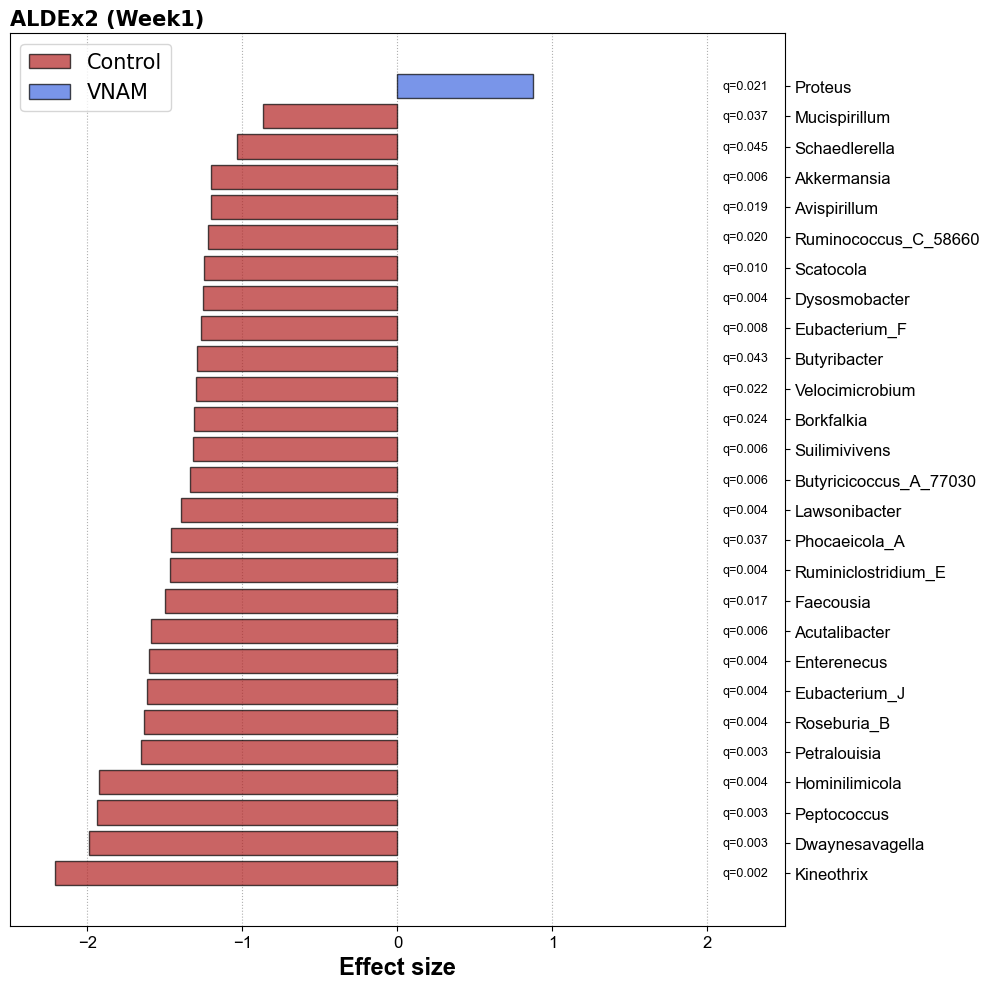

In [46]:
plt.figure(figsize=(10, 10))  #Edit

# Effect Size를 float로 변환
float_Before = Before['effect'].astype(float).tolist()
float_After = After['effect'].astype(float).tolist()

# x축 범위 설정
#Mini = math.floor(min(float_Before))
#Maxi = math.ceil(max(float_After))

##**##
all_effects = float_Before + float_After
if len(all_effects) == 0:
    raise ValueError("Effect 값이 없습니다. Before/After를 확인하세요.")

Mini = math.floor(min(all_effects))
Maxi = math.ceil(max(all_effects))
##**##

x_range = list(range(Mini-10, Maxi+10, 1))  # xticks 간격 조절
plt.xticks(x_range, fontsize=12, fontname='Arial')

# 양수와 음수 데이터 분리
negative_effects = df_ld3_masked[df_ld3_masked['effect'] < 0]  #Edit: masking 안된 데이터 쓰려면 이 부분 변경
positive_effects = df_ld3_masked[df_ld3_masked['effect'] > 0]  #Edit: masking 안된 데이터 쓰려면 이 부분 변경

y_pos_negative = np.arange(len(Before))
y_pos_positive = len(Before) + np.arange(len(After))

bars_negative = plt.barh(y_pos_negative, Before['effect'], color='firebrick', alpha=0.7, edgecolor='k', label='Control', zorder=3)  #Edit
bars_positive = plt.barh(y_pos_positive, After['effect'], color='royalblue', alpha=0.7, edgecolor='k', label='VNAM', zorder=3)  #Edit
## LDA plot default color: negative-'r' / positive-'g'



# 눈금선을 점선으로 설정, 막대 그래프 뒤로 보내기
plt.grid(True, axis='x', linestyle='dotted', zorder=0)
        
# y축에 카테고리 이름 표시
plt.yticks(np.concatenate([y_pos_negative, y_pos_positive]), 
           np.concatenate([negative_effects['Genus'], positive_effects['Genus']]),  #Edit: 비교 원하는 Taxa Level 입력
           fontsize=12,
           fontname='Arial')


# q-value를 조건부로 표시
df_ld3_masked['q-val'] = pd.to_numeric(df_ld3_masked['q-val'], errors='coerce')
for i, q_val in enumerate(df_ld3_masked['q-val']):
    if q_val < 0.001:
        q_val_str = f'{q_val:.2e}'  # 지수 표기법
    else:
        q_val_str = f'{q_val:.3f}'  # 일반 표기법

    plt.text(
        2.1,  #Edit: x축 위치를 그래프의 오른쪽 바깥쪽으로 설정 (5로 이동)
        i, 
        f'q={q_val_str}',  # 조건부로 p-value 표시
        va='center', ha='left', color='k', fontsize=9, fontname='Arial',
        transform=plt.gca().transData
    )    

plt.xlim(-2.5, 2.5)  #Edit
plt.xlabel('Effect size', fontsize=17, fontname='Arial', fontweight='bold')
plt.ylabel('')
ax = plt.gca()
ax.yaxis.set_ticks_position('right')
plt.title('ALDEx2 (Week1)', fontsize=15, loc='left', fontweight='bold')
#plt.legend(bbox_to_anchor=(1.01, 1.01), fontsize=8.5, edgecolor='grey')

plt.tight_layout()

plt.legend(fontsize=15, loc='best')  #Edit

plt.savefig("aldex2_fdr_BKY.png", dpi=500, bbox_inches='tight')

plt.show()